In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
path = '/content/drive/MyDrive/Document/retail_store_inventory.csv'

In [11]:
df = pd.read_csv(path, index_col='Date', parse_dates=True)

In [13]:
print("Tampilan Data Awal:")
display(df.head())

Tampilan Data Awal:


,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
Date,,,,,,,,,,,,,,
2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


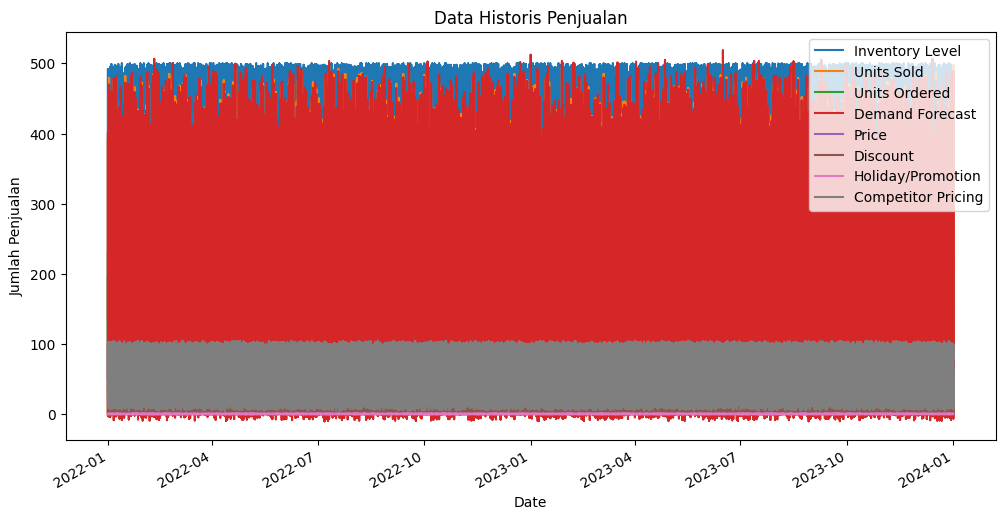

In [14]:
df.plot(figsize=(12, 6), title="Data Historis Penjualan")
plt.ylabel("Jumlah Penjualan")
plt.show()

In [15]:
target_col = 'Penjualan'

In [16]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [17]:
print(f"Jumlah Data Latih: {len(train)}")
print(f"Jumlah Data Uji: {len(test)}")

Jumlah Data Latih: 58480
Jumlah Data Uji: 14620


In [23]:
target_col = 'Units Sold'

ses_model = SimpleExpSmoothing(train[target_col]).fit(optimized=True)
test_predictions_ses = ses_model.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [24]:
des_model = ExponentialSmoothing(train[target_col], trend='add', seasonal=None).fit(optimized=True)
test_predictions_des = des_model.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [25]:
test['SES_Pred'] = test_predictions_ses.values
test['DES_Pred'] = test_predictions_des.values

/tmp/ipykernel_5357/4143433640.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['SES_Pred'] = test_predictions_ses.values
/tmp/ipykernel_5357/4143433640.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['DES_Pred'] = test_predictions_des.values


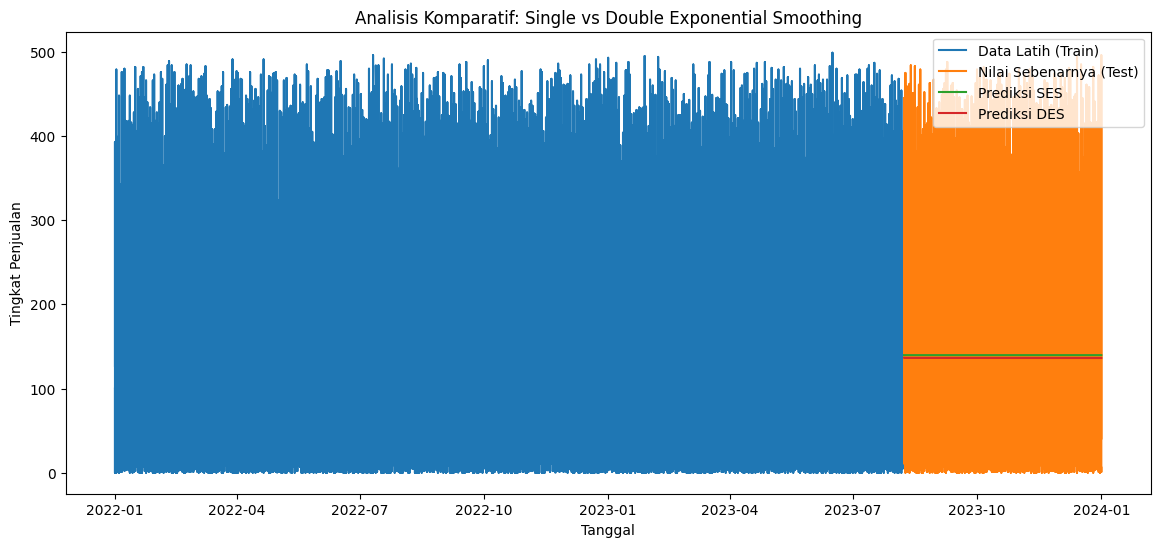

In [26]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train[target_col], label='Data Latih (Train)')
plt.plot(test.index, test[target_col], label='Nilai Sebenarnya (Test)')
plt.plot(test.index, test['SES_Pred'], label='Prediksi SES')
plt.plot(test.index, test['DES_Pred'], label='Prediksi DES')
plt.title("Analisis Komparatif: Single vs Double Exponential Smoothing")
plt.xlabel("Tanggal")
plt.ylabel("Tingkat Penjualan")
plt.legend()
plt.show()

In [27]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- Performa {model_name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}\n")

In [28]:
evaluate_model(test[target_col], test['SES_Pred'], "Single Exponential Smoothing")
evaluate_model(test[target_col], test['DES_Pred'], "Double Exponential Smoothing")

--- Performa Single Exponential Smoothing ---
MAE  : 89.42
RMSE : 108.35

--- Performa Double Exponential Smoothing ---
MAE  : 88.78
RMSE : 108.28



In [29]:
best_rmse = min(sqrt(mean_squared_error(test[target_col], test['SES_Pred'])),
                sqrt(mean_squared_error(test[target_col], test['DES_Pred'])))

In [30]:
print("--- Kesimpulan Manajerial ---")
print(f"Error prediksi (RMSE) terendah adalah sekitar {best_rmse:.2f} unit.")
print("Dalam konteks Manajemen Persediaan, nilai RMSE ini dapat dijadikan estimasi standar deviasi error peramalan.")
print(f"Untuk mencegah kehabisan stok (stockout), manajemen disarankan untuk menyiapkan Safety Stock tambahan proporsional dengan angka {best_rmse:.2f} unit ini, dikalikan dengan Z-score dari *Service Level* yang diinginkan.")

--- Kesimpulan Manajerial ---
Error prediksi (RMSE) terendah adalah sekitar 108.28 unit.
Dalam konteks Manajemen Persediaan, nilai RMSE ini dapat dijadikan estimasi standar deviasi error peramalan.
Untuk mencegah kehabisan stok (stockout), manajemen disarankan untuk menyiapkan Safety Stock tambahan proporsional dengan angka 108.28 unit ini, dikalikan dengan Z-score dari *Service Level* yang diinginkan.
